In [1]:
# ============================================
# Prodigy InfoTech Internship
# Task 02
# Data Cleaning and Exploratory Data Analysis
# Titanic Dataset
# ============================================

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

%matplotlib inline

In [6]:
train = pd.read_csv(r"D:\Datascience_Internship\Prodigy_Task2\train.csv")

test = pd.read_csv(r"D:\Datascience_Internship\Prodigy_Task2\test.csv")

gender = pd.read_csv(r"D:\Datascience_Internship\Prodigy_Task2\gender_submission.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [7]:
print("Training Dataset")
display(train.head())

print("Testing Dataset")
display(test.head())

print("Gender Submission Dataset")
display(gender.head())

Training Dataset


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Testing Dataset


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Gender Submission Dataset


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [8]:
print("TRAIN INFO")
train.info()

print("\nTEST INFO")
test.info()

TRAIN INFO
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

TEST INFO
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass      

In [9]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("Submission Shape:", gender.shape)

Train Shape: (891, 12)
Test Shape: (418, 11)
Submission Shape: (418, 2)


In [10]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

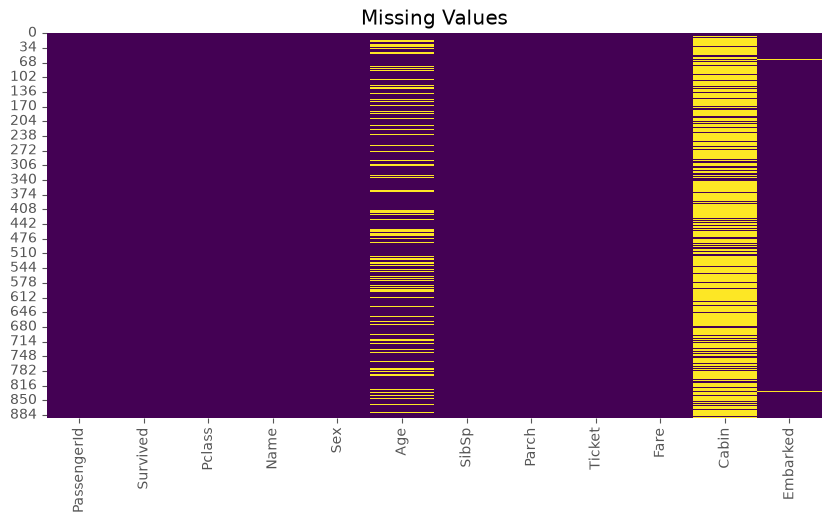

In [11]:
plt.figure(figsize=(10,5))
sns.heatmap(train.isnull(),cbar=False,cmap="viridis")
plt.title("Missing Values")
plt.show()

In [14]:
# Fill missing values

train["Age"] = train["Age"].fillna(train["Age"].median())

train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])

train["Cabin"] = train["Cabin"].fillna("Unknown")

print("Missing values handled successfully!")

Missing values handled successfully!


In [15]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [16]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


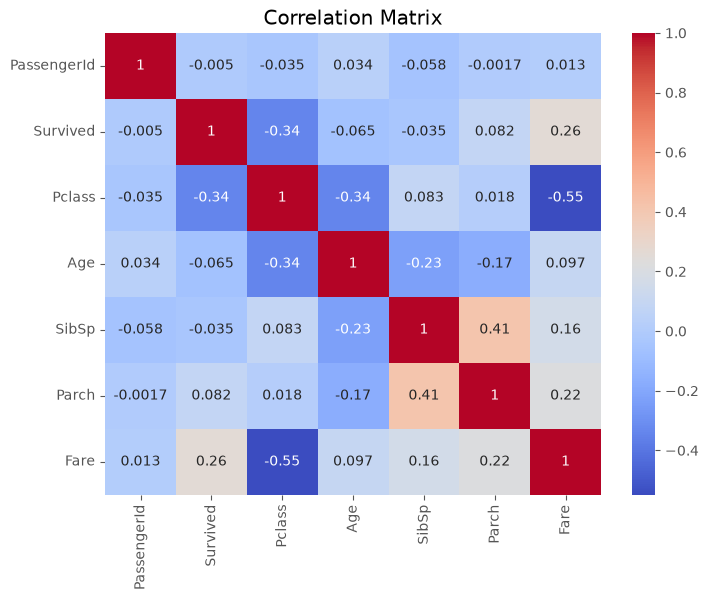

In [17]:
numeric_train = train.select_dtypes(include=["number"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_train.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

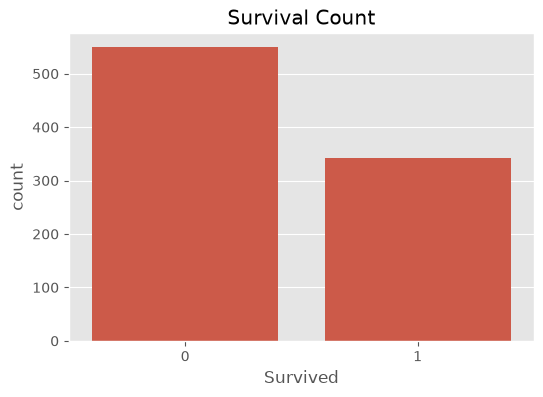

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x="Survived",data=train)
plt.title("Survival Count")
plt.show()

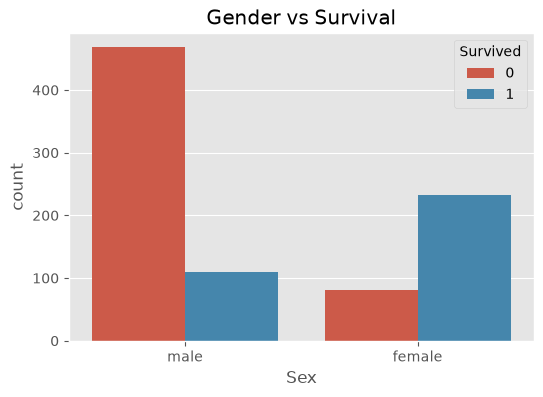

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex",hue="Survived",data=train)
plt.title("Gender vs Survival")
plt.show()

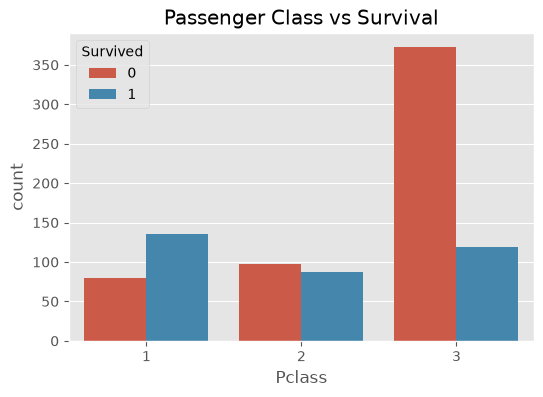

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass",hue="Survived",data=train)
plt.title("Passenger Class vs Survival")
plt.show()

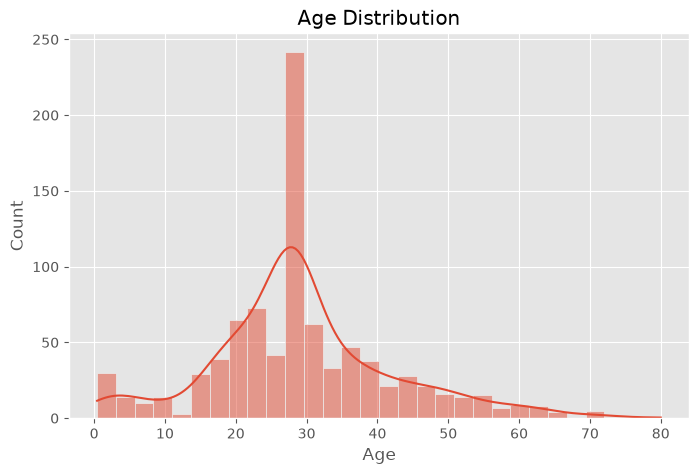

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(train["Age"],bins=30,kde=True)
plt.title("Age Distribution")
plt.show()

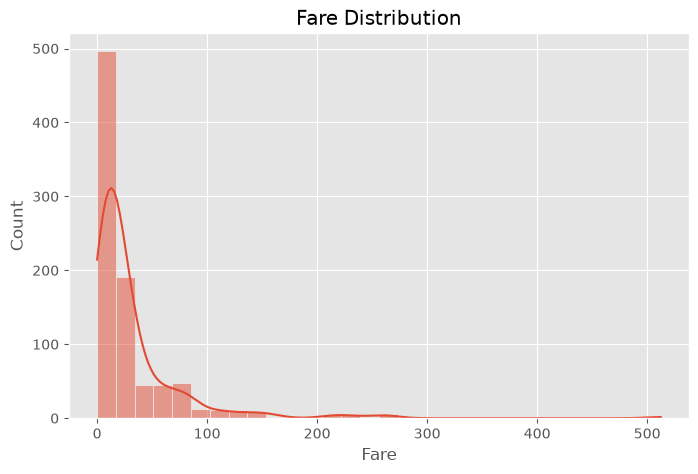

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(train["Fare"],bins=30,kde=True)
plt.title("Fare Distribution")
plt.show()

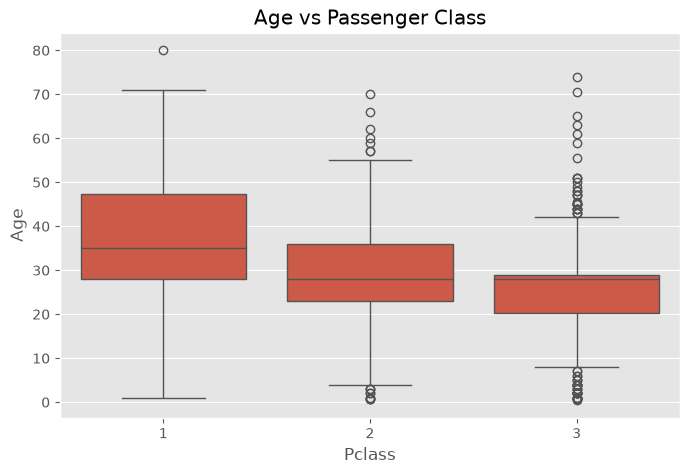

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Pclass",y="Age",data=train)
plt.title("Age vs Passenger Class")
plt.show()

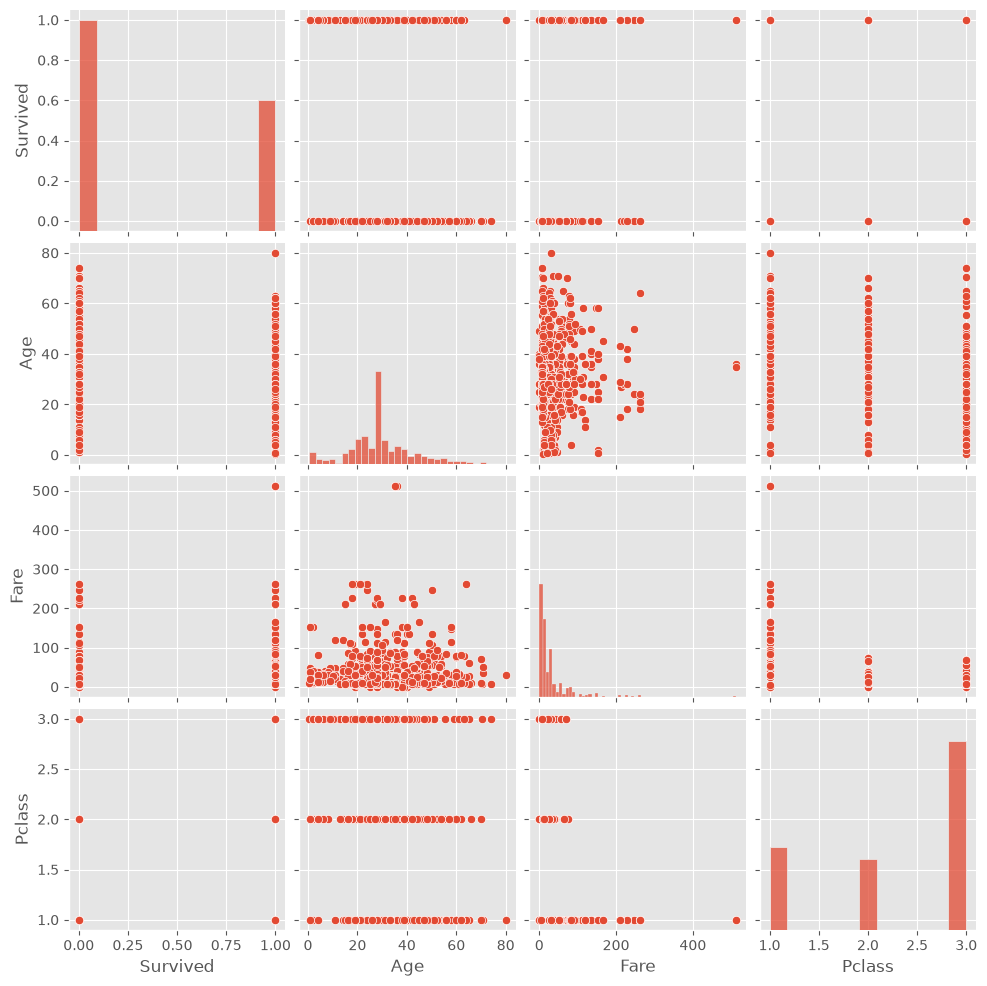

In [24]:
sns.pairplot(train[["Survived","Age","Fare","Pclass"]])
plt.show()

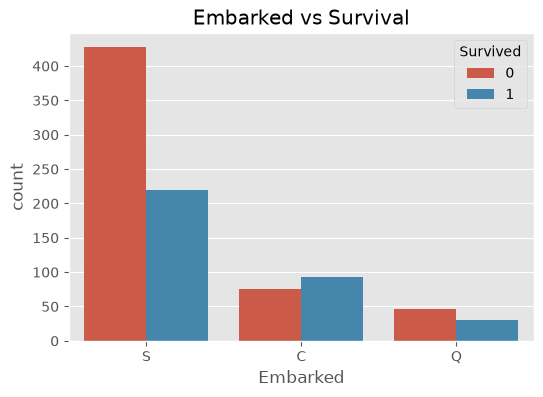

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="Embarked",hue="Survived",data=train)
plt.title("Embarked vs Survival")
plt.show()

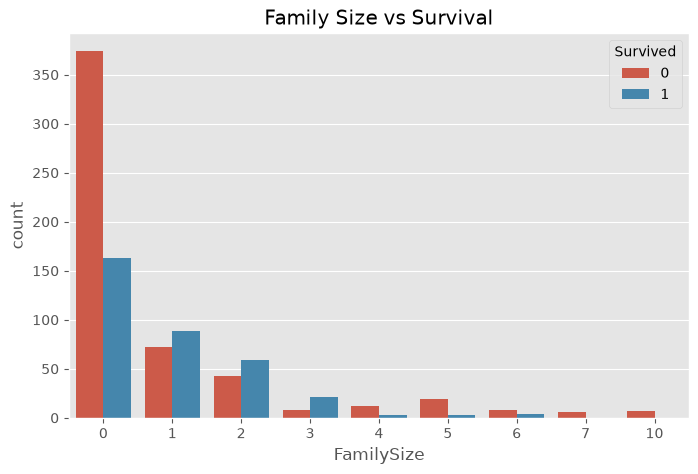

In [26]:
train["FamilySize"]=train["SibSp"]+train["Parch"]

plt.figure(figsize=(8,5))
sns.countplot(x="FamilySize",hue="Survived",data=train)
plt.title("Family Size vs Survival")
plt.show()

In [27]:
train.groupby("Survived")["Age"].mean()

Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

In [28]:
train.groupby("Survived")["Fare"].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

In [29]:
merged=test.merge(gender,on="PassengerId")

merged.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,1
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,1


In [30]:
train.to_csv("cleaned_train.csv",index=False)

In [31]:
print("""
EDA Completed Successfully

Key Findings:

1. Females survived more than males.
2. First-class passengers had the highest survival rate.
3. Younger passengers had slightly better survival chances.
4. Higher ticket fare generally indicates higher survival.
5. Age had missing values which were replaced with the median.
6. Cabin had many missing values and was filled with 'Unknown'.
7. Embarked missing values were filled with the mode.
8. Family size influences survival probability.
""")


EDA Completed Successfully

Key Findings:

1. Females survived more than males.
2. First-class passengers had the highest survival rate.
3. Younger passengers had slightly better survival chances.
4. Higher ticket fare generally indicates higher survival.
5. Age had missing values which were replaced with the median.
6. Cabin had many missing values and was filled with 'Unknown'.
7. Embarked missing values were filled with the mode.
8. Family size influences survival probability.

